In [1]:
import pandas as pd

df = pd.read_csv('data/train.csv')
print(df.head)
print(df.shape)

<bound method NDFrame.head of        label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0          1       0       0       0       0       0       0       0       0   
1          0       0       0       0       0       0       0       0       0   
2          1       0       0       0       0       0       0       0       0   
3          4       0       0       0       0       0       0       0       0   
4          0       0       0       0       0       0       0       0       0   
...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
41995      0       0       0       0       0       0       0       0       0   
41996      1       0       0       0       0       0       0       0       0   
41997      7       0       0       0       0       0       0       0       0   
41998      6       0       0       0       0       0       0       0       0   
41999      9       0       0       0       0       0       0       0       0   

       pi

In [2]:
input_features = df.columns.drop('label')
target = 'label'
print(input_features)

Index(['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='str', length=784)


In [4]:
X_train = df[input_features]
Y_train = df[target]
print(X_train.shape)
print(Y_train.shape)

(42000, 784)
(42000,)


In [7]:
import torch

X_train_tensor = torch.tensor(X_train.values, dtype = torch.float32)
Y_train_tensor = torch.tensor(Y_train.values, dtype = torch.long)

In [8]:
print(X_train_tensor.shape)
print(Y_train_tensor.shape)

torch.Size([42000, 784])
torch.Size([42000])


In [9]:
from torch.utils.data import Dataset

class DigitDataset(Dataset):

    def __init__(Self, X, Y):
        Self.X = X
        Self.Y = Y

    def __len__(Self):
        return len(Self.X)

    def __getitem__(Self, idx):
        return Self.X[idx], Self.Y[idx]


In [10]:
from torch.utils.data import DataLoader

dataset = DigitDataset(X_train_tensor, Y_train_tensor)
dataLoader = DataLoader(dataset, batch_size = 32, shuffle = True)

for X_batch, Y_batch in dataLoader:
    print(X_batch.shape)
    print(Y_batch.shape)
    break

torch.Size([32, 784])
torch.Size([32])


In [41]:
import torch.nn as nn

class DigitCNNModel(nn.Module):

    def __init__(Self):
        super().__init__()
        Self.conv1 = nn.Conv2d(1, 5, kernel_size = 3, padding = 2)
        Self.conv2 = nn.Conv2d(5, 3, kernel_size = 2, padding = 2)
        Self.relu = nn.ReLU()
        Self.fc = nn.Linear(33*33*3, 10)
        Self.maxpool = nn.MaxPool2d(2)

    def forward(Self, x):
        x = Self.conv1(x)
        x = Self.relu(x)

        x = Self.conv2(x)
        x = Self.relu(x)

        x = torch.flatten(x, start_dim = 1)
        x = Self.fc(x)

        return x

In [50]:
model = DigitCNNModel()
print(model)

DigitCNNModel(
  (conv1): Conv2d(1, 5, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(5, 3, kernel_size=(2, 2), stride=(1, 1), padding=(2, 2))
  (relu): ReLU()
  (fc): Linear(in_features=3267, out_features=10, bias=True)
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


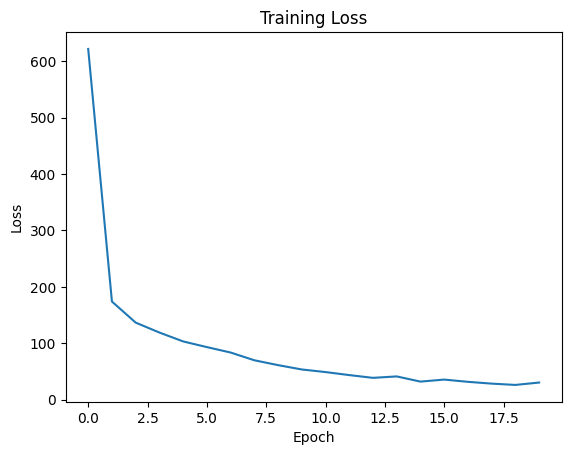

In [51]:
criterion = nn.CrossEntropyLoss()
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr = 0.001)

losses = []

for epoch in range(20):
    total_loss = 0
    for X_batch, Y_batch in dataLoader:
        X_reshaped = X_batch.reshape(-1, 1, 28, 28)
        outputs = model(X_reshaped)
        loss = criterion(outputs, Y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss)

import matplotlib.pyplot as plt

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

In [52]:
model.eval()

with torch.no_grad():
    outputs = model(X_train_tensor.reshape(-1, 1, 28, 28))
    preds = outputs.argmax(dim = 1)
    correct = (preds == Y_train_tensor).sum().item()
    total = Y_train_tensor.shape[0]
    print((correct/total)*100)

99.55000000000001


In [54]:
df_test = pd.read_csv('data/test.csv')
X_test = df_test[input_features]
X_test_tensor = torch.tensor(X_test.values, dtype = torch.float32)

outputs = model(X_test_tensor.reshape(-1, 1, 28, 28))
predictions_test = outputs.argmax(dim = 1)
image_ids = list(range(1, X_test.shape[0] + 1))
submission = pd.DataFrame({
    'ImageId': image_ids,
    'label': predictions_test
})

submission.to_csv('submissioncnn.csv', index = False)